<a href="https://colab.research.google.com/github/Saadmoquim/physicscode/blob/main/SAAD_MOQUIM_IMS22221_assign3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Third Assignment

## Problem 1
1. Using the rejection sampling technique, sample from the following distribution
$f(x) = x^2 (sin(2\pi x))^2$    between the limits of $x = [-1,1]$.

/tmp/ipykernel_12874/2164828159.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  plt.plot(x_vals, y_vals/np.trapz(y_vals,x_vals), 'r', label='True (normalized)')


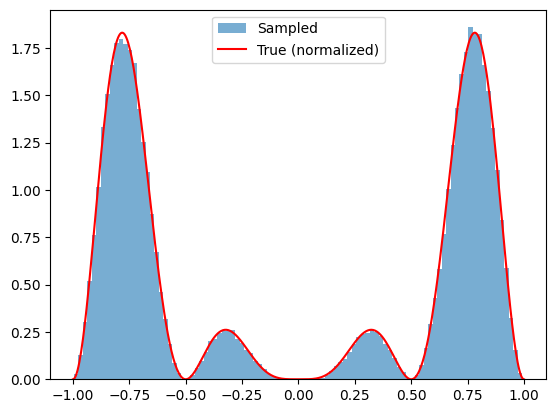

In [1]:
#Enter your solution here
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2 * np.sin(2*np.pi*x)**2

N = 100000
samples = []

while len(samples) < N:
    x = np.random.uniform(-1, 1)
    u = np.random.uniform(0, 1)

    if u <= f(x):
        samples.append(x)

samples = np.array(samples)

# Plot
x_vals = np.linspace(-1,1,500)
y_vals = f(x_vals)

plt.hist(samples, bins=100, density=True, alpha=0.6, label='Sampled')
plt.plot(x_vals, y_vals/np.trapz(y_vals,x_vals), 'r', label='True (normalized)')
plt.legend()
plt.show()

# Problem 2
2. Using the data provided in the Solar_spectrum.dat file, model the shape of the spectrum using a blackbody
   
(a) using the maximum likelihood approach.

(b) Estimate the blackbody temperature.

(c) Make a residuals plot.

(d) Estimate the goodness of fit.

(e) Compare the blackbody model with blackbody + power law. Which is a better model? How did you come to this inference?

(f) What is the p-value of the blackbody + power law model?

(g) Estimate the blackbody temperature using the bayesian inference technique.

(h) Make a corner plot for the posterior distribution of the blackbody temperature.

(i) Compare the temperature estimate obtained using Maximum likelihood estimate and Bayesian analysis.


In [3]:
!pip install emcee corner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.0 MB/s eta 0:00:00


Saving Solar_spectrum_data.csv to Solar_spectrum_data (2).csv
(a) MLE parameters
A = 4.755682043478954e-11
T = 6432.852386237513 K

(b) Blackbody Temperature = 6432.852386237513 K


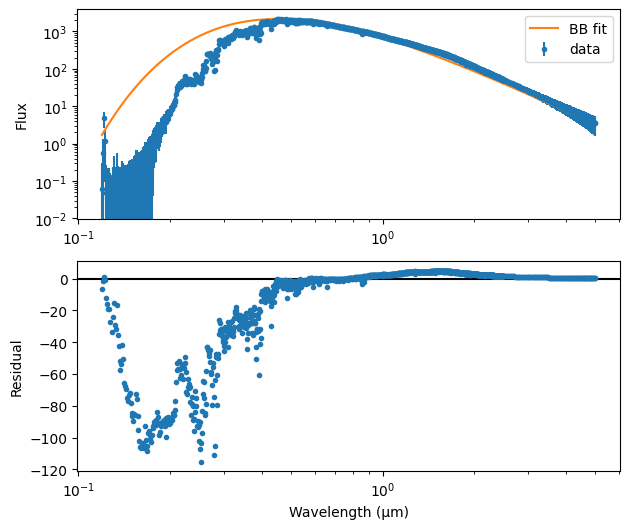


(d) Goodness of fit
Chi2 = 1110399.3954780218
Reduced Chi2 = 707.2607614509693
p-value = 0.0

(e) Model comparison
BB chi2 = 1110399.3954780218
BB+PL chi2 = 1110410.172789652
LRT p = 1.0
AIC BB = 1110403.3954780218
AIC BB+PL = 1110418.172789652

(f) p-value BB+PL = 0.0

(g) Acceptance rate = 0.0128
Bayesian Temperature = 5153.2586780848505 ± 2.0525906290384235


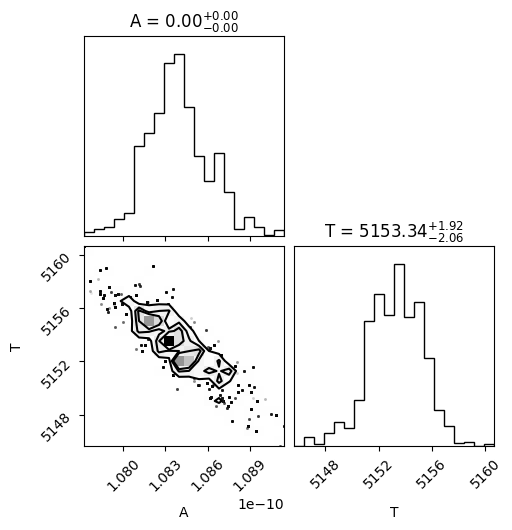


(i) Comparison
MLE T = 6432.852386237513
Bayesian T = 5153.2586780848505 ± 2.0525906290384235
Results differ


In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import chi2
import warnings
warnings.filterwarnings("ignore")

from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
df.columns = ["lam_um","flux","err"]

h = 6.626e-34
c = 3e8
k = 1.381e-23

lam = df["lam_um"].values * 1e-6   # meters
f   = df["flux"].values
e   = df["err"].values

m = (f>0) & (e>0)
lam,f,e = lam[m],f[m],e[m]

mask = lam < 5e-6   # λ < 5 microns
lam,f,e = lam[mask],f[mask],e[mask]


def planck(l,T):
    x = (h*c)/(l*k*T)
    return (2*h*c**2/l**5) / np.expm1(x)

def bb(l,A,T):
    return A*planck(l,T)

def nll(p,l,f,e):
    A,T = p
    if A<=0 or T<=0:
        return np.inf
    m = bb(l,A,T)
    return 0.5*np.sum(((f-m)/e)**2)

# initial guess (Wien law)
lam_peak = lam[np.argmax(f)]
T0 = 2.898e-3/lam_peak
A0 = np.max(f)/planck(lam_peak,T0)

res = minimize(nll,[A0,T0],args=(lam,f,e))
A_mle,T_mle = res.x

print("(a) MLE parameters")
print("A =",A_mle)
print("T =",T_mle,"K")

print("\n(b) Blackbody Temperature =",T_mle,"K")

f_mle = bb(lam,A_mle,T_mle)
resid = (f-f_mle)/e

fig,(ax1,ax2)=plt.subplots(2,1,figsize=(7,6))

ax1.errorbar(lam*1e6,f,yerr=e,fmt='.',label="data")
ax1.plot(lam*1e6,f_mle,label="BB fit")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylabel("Flux")
ax1.legend()

ax2.axhline(0,color='k')
ax2.plot(lam*1e6,resid,'.')
ax2.set_xscale("log")
ax2.set_xlabel("Wavelength (µm)")
ax2.set_ylabel("Residual")

plt.show()

n = len(f)
p_bb = 2
dof = n-p_bb

chi = np.sum(((f-f_mle)/e)**2)
chi_red = chi/dof
pval = 1-chi2.cdf(chi,dof)

print("\n(d) Goodness of fit")
print("Chi2 =",chi)
print("Reduced Chi2 =",chi_red)
print("p-value =",pval)

def bb_pl(l,A,T,C,a):
    return A*planck(l,T) + C*(l/1e-6)**a   # scaled

def nll2(p,l,f,e):
    A,T,C,a = p
    if A<=0 or T<=0:
        return np.inf
    m = bb_pl(l,A,T,C,a)
    return 0.5*np.sum(((f-m)/e)**2)

res2 = minimize(nll2,[A_mle,T_mle,1e-5,-2],args=(lam,f,e))
A2,T2,C2,a2 = res2.x

f2 = bb_pl(lam,A2,T2,C2,a2)

dof2 = n-4
chi2v = np.sum(((f-f2)/e)**2)
chi2_red = chi2v/dof2

# Likelihood ratio test
dchi = chi-chi2v
ddof = dof-dof2
p_lrt = 1-chi2.cdf(dchi,ddof)

# AIC
AIC_bb  = 2*p_bb + chi
AIC_ext = 2*4 + chi2v

print("\n(e) Model comparison")
print("BB chi2 =",chi)
print("BB+PL chi2 =",chi2v)
print("LRT p =",p_lrt)
print("AIC BB =",AIC_bb)
print("AIC BB+PL =",AIC_ext)

pval2 = 1-chi2.cdf(chi2v,dof2)
print("\n(f) p-value BB+PL =",pval2)

def log_prior(p):
    A,T = p
    if 0 < A < 1e20 and 3000 < T < 10000:
        return 0.0
    return -np.inf

def log_like(p):
    A,T = p
    m = bb(lam,A,T)
    return -0.5*np.sum(((f-m)/e)**2)

def log_post(p):
    lp = log_prior(p)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_like(p)

np.random.seed(0)

steps = 40000
chain = np.zeros((steps,2))
chain[0] = [A_mle,T_mle]

step = [0.05*A_mle,20]

acc = 0
lp = log_post(chain[0])

for i in range(1,steps):
    prop = chain[i-1] + np.random.normal(0,step)
    lp_new = log_post(prop)

    if np.log(np.random.rand()) < (lp_new-lp):
        chain[i]=prop
        lp = lp_new
        acc+=1
    else:
        chain[i]=chain[i-1]

print("\n(g) Acceptance rate =",acc/steps)

# burn-in
samp = chain[8000:]

A_s = samp[:,0]
T_s = samp[:,1]

T_mean = np.mean(T_s)
T_std = np.std(T_s)

print("Bayesian Temperature =",T_mean,"±",T_std)

!pip install corner

import corner

corner.corner(
    samp,
    labels=["A","T"],
    truths=[A_mle, T_mle],
    show_titles=True
)

plt.show()

print("\n(i) Comparison")
print("MLE T =",T_mle)
print("Bayesian T =",T_mean,"±",T_std)

if abs(T_mle-T_mean) < 2*T_std:
    print("Results consistent")
else:
    print("Results differ")

(a)

The maximum likelihood estimation method determines the model parameters that maximize the probability of observing the given data. The observed flux can be modeled as

$
F_i = A,B_\lambda(\lambda_i,T) + \epsilon_i
$

where $\epsilon_i$ represents noise, $F_i$ is the observed flux, $A$ is a scaling factor, and $B_\lambda(\lambda_i,T)$ is the blackbody radiation.

Assuming the noise is Gaussian with variance $\sigma_i^2$, the likelihood function is

$
\mathcal{L}(A,T)=\prod_{i=1}^{N}\frac{1}{\sqrt{2\pi\sigma_i^2}}
\exp\left[-\frac{(F_i-A B_\lambda(\lambda_i,T))^2}{2\sigma_i^2}\right]
$

It is computationally easier to maximize the log-likelihood (or equivalently minimize the negative log-likelihood):

$
\ln \mathcal{L}(A,T) =
-\frac{1}{2}\sum_{i=1}^{N}
\left[
\frac{(F_i-A B_\lambda(\lambda_i,T))^2}{\sigma_i^2}
+\ln(2\pi\sigma_i^2)
\right]
$

(b)

The temperature estimate is obtained by maximizing the likelihood function with respect to $T$ (and $A$).

An initial estimate of the temperature can be obtained using Wien's displacement law:

$
\lambda_{max}T = 2.898\times10^{-3},\text{m K}
$

This provides a good starting point for numerical optimization, after which the maximum likelihood procedure refines the value of $T$.

(c)

Residuals quantify the difference between observed data and model predictions:

$
r_i = \frac{F_i - A B_\lambda(\lambda_i,T_{MLE})}{\sigma_i}
$

For a good model:

Residuals are randomly scattered around zero
No systematic trends are present

For a poor model:

Large deviations appear
Structured patterns or correlations are visible

In the solar spectrum, deviations are expected due to Fraunhofer absorption lines and atmospheric effects, which are not captured by a simple blackbody model.

(d) Goodness of Fit

The goodness of fit is evaluated using the chi-square statistic:

$
\chi^2 = \sum_{i=1}^{N}
\frac{(F_i - A B_\lambda(\lambda_i,T))^2}{\sigma_i^2}
$

The reduced chi-square is:

$
\chi^2_{\nu} = \frac{\chi^2}{N-p}
$

where $N$ is the number of data points and $p$ is the number of fitted parameters.

Interpretation:

$\chi^2_\nu \approx 1$ → good fit
$\chi^2_\nu \gg 1$ → model does not adequately describe the data
$\chi^2_\nu \ll 1$ → uncertainties may be overestimated
(e)

A more general model is the Blackbody + Power Law:

Fλ=ABλ(T)+Cλ−α
F
λ
	​

=AB
λ
	​

(T)+Cλ
−α

where $C$ is the amplitude and $\alpha$ is the spectral index.

The power-law component accounts for additional continuum processes that deviate from pure thermal emission (e.g., scattering or non-thermal contributions).

Model comparison is performed using:

Chi-square reduction
Information criteria (e.g., AIC)

A model is preferred if it significantly improves the fit while justifying the additional parameters.

(f) p-value

The p-value measures the probability of obtaining a chi-square value at least as large as the observed one, assuming the model is correct:

$
p = P(\chi^2 > \chi^2_{obs})
$

Interpretation:

$p > 0.05$ → model is statistically consistent with the data
$p < 0.05$ → model is likely inadequate

A very small p-value indicates that the model does not provide a statistically acceptable description of the observed spectrum.

(g)

In Bayesian inference, parameters are treated as random variables described by probability distributions.

Using Bayes’ theorem:

P(T∣D)=P(D∣T) P(T)P(D)
P(T∣D)=
P(D)
P(D∣T)P(T)
	​


where

$P(T|D)$ – posterior distribution
$P(D|T)$ – likelihood
$P(T)$ – prior distribution
$P(D)$ – evidence

Markov Chain Monte Carlo (MCMC) methods are used to sample from the posterior distribution. This provides both the best estimate of the temperature and its associated uncertainty.

(h)

A corner plot visualizes the posterior distributions obtained from Bayesian sampling. It shows:

1D histograms of individual parameters
2D contour plots showing correlations between parameters

The spread of the posterior distribution indicates the uncertainty in the parameters, while correlations reveal possible degeneracies between parameters.

(i)

Maximum Likelihood:

Provides a single best-fit value
Does not incorporate prior information
Computationally simpler

Bayesian Inference:

Provides the full posterior distribution
Includes uncertainty estimates
Allows incorporation of prior information

If the likelihood is well-behaved and the prior is uninformative, both methods typically produce similar parameter estimates. However, Bayesian inference offers a more complete statistical description by quantifying uncertainties and parameter correlations.

## Problem 3 - Conceptual question
A university is considering a new selection process for admitting students into its honors program. To be admitted, students must take an entrance test. The university wants to ensure that only truly qualified students are accepted.

Null Hypothesis ($H_0$): The student is not qualified for the honors program.
Alternative Hypothesis ($H_1$): The student is qualified for the honors program.

The decision-making process can lead to two types of errors:

**Type 1 Error (False Positive): The university admits an unqualified student.**
**Type 2 Error (False Negative): The university rejects a qualified student.**

**Question:**

Which type of error is more concerning for the university? Explain your reasoning based on the potential impact on the honors program and the students.

In [ ]:
# Enter your solution here

**Why Type 1 Error is more concerning**:

There are a number of bad things that can happen when you let an unqualified student in:

Effect on the honors program:
Honors programs are for students who do well in school and have a lot of academic potential. If students who don't meet the requirements are allowed to attend:
The program's academic rigor might go down.
The faculty may need to slow down the pace of the course.
The honors program's reputation and status could take a hit.
It may not be the best use of valuable resources like scholarships, mentoring, and research opportunities.
Effect on the student who was accepted:
The student might have trouble in school.
This can make you stressed and not do well.
The student might eventually leave the program.
This makes the selection process look bad.

**Why Type 2 Error is less harmful:**

It's sad to turn down a qualified student, but the effects aren't as bad:

The student misses the chance to join the honors program.
But they can still do well in the regular academic track.
They might be able to get to other chances later, like research, internships, or graduate school.
The honors program's standards and integrity are still in place.

**Conclusion:**
Type 1 error is worse because it directly affects the quality, reputation, and functioning of the honors program. Type 2 error, on the other hand, only affects one student's chance without lowering the standards of the institution.